# Imports

In [1]:
import os
import re
import sys
import h5py
import math
import copy
import time
import torch
import optuna

import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from scipy.stats import skew, kurtosis
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import RocCurveDisplay, auc, accuracy_score, roc_curve
from sklearn.preprocessing import RobustScaler, PowerTransformer, MinMaxScaler

# Function Definitions

In [2]:
def plot_feature_histograms(tensor, bins=500, figsize=(15, 15)):
    num_channels = tensor.shape[1]
    
    fig, axes = plt.subplots(num_channels, 1, figsize=figsize, constrained_layout=True)
    
    for i in range(num_channels):
        # Flattening all the sequence elements within a channel into a 1D array and excluding zeros
        feature_data = tensor[:, i, :, 0].flatten().numpy()
        feature_data_non_zero = feature_data[(feature_data != 0) & (feature_data != 1)]
        
        ax = axes[i]
        ax.hist(feature_data_non_zero, bins=bins)
        ax.set_title(f'Channel {i} (non-zero values)')
    
    plt.show()
       

def plot_feature_histograms_alt(tensor, bins=100, figsize=(15, 15)):
    num_samples = tensor.shape[0]
    sequence_length = tensor.shape[2]

    fig, axes = plt.subplots(sequence_length, 1, figsize=figsize, constrained_layout=True)

    for i in range(sequence_length):
        feature_data = tensor[:, :, i, 0].flatten().numpy()  # Flatten all channel data for a given sequence element
        feature_data_non_zero = feature_data[(feature_data != 0) & (feature_data != 1)]
        
        ax = axes[i]
        ax.hist(feature_data_non_zero, bins=bins)
        ax.set_title(f'Sequence element {i} across all channels')

    plt.show()
       

def calculate_feature_parameters(tensor):
    num_samples = tensor.shape[0]
    num_channels = tensor.shape[1]
    sequence_length = tensor.shape[2]

    parameters_list = []

    for i in range(num_channels):
        # Flattening all the sequence elements within a channel into a 1D array
        feature_data = tensor[:, i, :, 0].flatten().numpy()

        # Skewness and kurtosis
        feature_skewness = skew(feature_data)
        feature_kurtosis = kurtosis(feature_data)

        # IQR
        q1 = np.percentile(feature_data, 25)
        q3 = np.percentile(feature_data, 75)
        feature_iqr = q3 - q1

        # Min / Max
        feature_min = np.min(feature_data)
        feature_max = np.max(feature_data)
        min_max = feature_max - feature_min

        # Count number of zero values
        zero_count = np.count_nonzero(feature_data==0)

        parameters_list.append({
            'Channel': i,
            'Skewness': feature_skewness,
            'Kurtosis': feature_kurtosis,
            'IQR': feature_iqr,
            '0/': zero_count,
            'Min/Max': min_max
        })

    parameters = pd.DataFrame(parameters_list)

    return parameters


def preprocess_features_complete(X_train, X_val, X_test, preprocessing_methods):
    # Assuming X_train, X_val and X_test are 4D tensors of shape (n_channels, n_samples, seq_length, 1)
    X_train_pp = torch.clone(X_train)
    X_val_pp = torch.clone(X_val)
    X_test_pp = torch.clone(X_test)
    
    scalers = {}
    EPSILON = 1e-8

    for channel, method in preprocessing_methods.items():
        train_feature = X_train[channel, :, :, 0]  # Shape: (n_samples, seq_length)

        if method == "custom_scaling":
            non_zero_mask = train_feature != 0
            mean = train_feature[non_zero_mask].mean()
            std = train_feature[non_zero_mask].std()
            scalers[channel] = (mean, std)

        elif method == "robust_scaling":
            scaler = RobustScaler()
            scaler.fit(train_feature.reshape(-1, 1))
            scalers[channel] = scaler

        elif method == "yeo_johnson_power_transform":
            pt = PowerTransformer(method='yeo-johnson')
            pt.fit((train_feature + EPSILON).reshape(-1, 1))
            scalers[channel] = pt

        elif method == "min_max_normalization":
            scaler = MinMaxScaler()
            scaler.fit(train_feature.reshape(-1, 1))
            scalers[channel] = scaler

        else:
            print(f"Warning: unrecognized preprocessing method '{method}' for channel {channel}")

    for channel, method in preprocessing_methods.items():
        if method == "custom_scaling":
            mean, std = scalers[channel]
            non_zero_mask = X_train[channel, :, :, 0] != 0
            X_train_pp[channel, :, :, 0][non_zero_mask] = (X_train[channel, :, :, 0][non_zero_mask] - mean) / std
            X_train_pp[channel, :, :, 0][~non_zero_mask] = 0
            non_zero_mask = X_val[channel, :, :, 0] != 0
            X_val_pp[channel, :, :, 0][non_zero_mask] = (X_val[channel, :, :, 0][non_zero_mask] - mean) / std
            X_val_pp[channel, :, :, 0][~non_zero_mask] = 0
            non_zero_mask = X_test[channel, :, :, 0] != 0
            X_test_pp[channel, :, :, 0][non_zero_mask] = (X_test[channel, :, :, 0][non_zero_mask] - mean) / std
            X_test_pp[channel, :, :, 0][~non_zero_mask] = 0

        elif method in ["robust_scaling", "yeo_johnson_power_transform", "min_max_normalization"]:
            scaler = scalers[channel]
            for i in range(X_train.shape[1]):
                for j in range(X_train.shape[2]):
                    X_train_pp[channel, i, j, 0] = torch.tensor(scaler.transform(X_train[channel, i, j, 0].reshape(-1, 1)).squeeze())
                    X_val_pp[channel, i, j, 0] = torch.tensor(scaler.transform(X_val[channel, i, j, 0].reshape(-1, 1)).squeeze())
                    X_test_pp[channel, i, j, 0] = torch.tensor(scaler.transform(X_test[channel, i, j, 0].reshape(-1, 1)).squeeze())
                    
    return X_train_pp, X_val_pp, X_test_pp


def train_model(model, criterion, optimizer, scheduler, dataloaders, num_epochs=25, patience=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_acc = 0.0

    # Early stopping details
    n_epochs_stop = patience
    min_val_loss = np.Inf
    epochs_no_improve = 0

    # to track the training and validation loss over epochs
    train_loss_history = []
    valid_loss_history = []
    train_acc_history = []
    valid_acc_history = []
    
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    labels = labels.unsqueeze(1) # Add an extra dimension
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                preds = outputs > 0.5
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val':
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    print(f'Early stopping counter: {epochs_no_improve} out of {n_epochs_stop}')
                    # Check early stopping condition
                    if epochs_no_improve == n_epochs_stop:
                        print('Early stopping!')
                        time_elapsed = time.time() - since
                        print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
                        print('Best val Loss: {:4f}'.format(best_loss))
                        # Load best model weights
                        model.load_state_dict(best_model_wts)
                        return model, train_loss_history, valid_loss_history, train_acc_history, valid_acc_history
                    
            # record the loss and accuracy history
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)
            else:
                valid_loss_history.append(epoch_loss)
                valid_acc_history.append(epoch_acc)
                
        # Step the scheduler
        scheduler.step()
        print(f'Learning Rate: {scheduler.get_last_lr()[0]}')
        print(f'Best validation loss so far: {best_loss}')
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    
    # return the model along with the historical data
    return model, train_loss_history, valid_loss_history, train_acc_history, valid_acc_history


def test_model(model, dataloader):
    model.eval()  # Set model to evaluation mode
    
    # These lists will keep track of the model's scores, as well as the true labels
    y_score = []
    y_true = []
    
    # Disabling gradient calculation. We're only predicting, not training
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
            
            y_score.extend(probs.cpu().numpy().tolist())
            y_true.extend(labels.cpu().numpy().tolist())
    
    # Compute ROC curve and ROC area for each class
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


# Data Pre-Processing

In [3]:
def to_categorical(labels, num_classes=None):
    """One-hot encodes class labels.

    **Arguments**

    - **labels** : _1-d numpy.ndarray_
        - Labels in the range `[0,num_classes)`.
    - **num_classes** : {_int_, `None`}
        - The total number of classes. If `None`, taken to be the 
        maximum label plus one.

    **Returns**

    - _2-d numpy.ndarray_
        - The one-hot encoded labels.
    """

    # get num_classes from max label if None
    if num_classes is None:
        num_classes = np.int(np.max(labels)) + 1

    y = np.asarray(labels, dtype=int)
    n = y.shape[0]
    categorical = np.zeros((n, num_classes))

    # index into array and set appropriate values to 1
    categorical[np.arange(n), y] = 1

    return categorical


def load_h5(h5_filename, mode='class', unsup=False, glob=False, nevts=-1):

    global_pl = []
    f = h5py.File(h5_filename,'r')
    nevts=int(nevts)
    data = f['data']

    label_np = None  # Initialize label_np

    if mode == 'class':
        label = f['pid']
        print("label", label)
        label_np = np.array(label)
        print("label_np", label_np)

        label_train = np.where(label_np > 1, 0, label_np)

        # label_train = label_np[label_np > 1] = 0
        print("label_train", label_train)

    elif mode == 'seg':
        label = f['label']
    else:
        print('No mode found')
    
    if glob:
        global_pl = f['global']
        return (data, label, global_pl, label_np)  # Return label_np as well

    print("loaded {0} events".format(data.shape[1]))

    data = [data[key] for key in range(data.shape[0])]
    print("data", len(data))

    # label = to_categorical(label, num_classes=2)
    label = to_categorical(label_train, num_classes=2)
    print("label", label)

    return (data, label, label_np)  # 22/05 Return label_np as well
 


def load_data():

    X_train, Y_train, label_np_train = load_h5('../Data/train_cnn1d_splitted.h5')
    X_val, Y_val, label_np_val = load_h5('../Data/validation_cnn1d_splitted.h5')
    X_test, Y_test, label_np_test = load_h5('../Data/test_cnn1d_splitted.h5')

    return X_train, X_val, X_test, Y_train, Y_val, Y_test, label_np_train, label_np_val, label_np_test


"""
Note that process types are tagged as follows:
    ttbarZ : 5
    ttbarWW : 4
    ttbarW : 3
    ttbarHiggs : 2
    4top : 1
"""

X_train, X_val, X_test, Y_train, Y_val, Y_test, label_np_train, label_np_val, label_np_test = load_data()



#print("X_train", X_train)
# print("X_val", X_val)
# print("X_test", X_test)

# print("Y_train", Y_train)
# print("Y_val", Y_val)
# print("Y_test", Y_test)


print("len of X_train", len(X_train))
print("len of X_val", len(X_val))
#print("len of X_test", len(X_test))

#print("len of Y_train", len(Y_train))
#print("len of Y_val", len(Y_val))
#print("len of Y_test", len(Y_test))

print("Type of X_train", type(X_train))
print("Type of X_val", type(X_val))

print("Shape of X_train", np.shape(X_train))
print("Shape of X_val", np.shape(X_val))

print("Shape of Y_train", np.shape(Y_train))
print("Shape of Y_val", np.shape(Y_val))

label <HDF5 dataset "pid": shape (241658,), type "<f8">
label_np [4. 2. 1. ... 1. 3. 3.]
label_train [0. 0. 1. ... 1. 0. 0.]
loaded 241658 events
data 11
label [[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [0. 1.]
 [1. 0.]
 [1. 0.]]
label <HDF5 dataset "pid": shape (30207,), type "<f8">
label_np [5. 2. 1. ... 1. 2. 5.]
label_train [0. 0. 1. ... 1. 0. 0.]
loaded 30207 events
data 11
label [[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [0. 1.]
 [1. 0.]
 [1. 0.]]
label <HDF5 dataset "pid": shape (30207,), type "<f8">
label_np [4. 3. 1. ... 1. 1. 1.]
label_train [0. 0. 1. ... 1. 1. 1.]
loaded 30207 events
data 11
label [[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [0. 1.]
 [0. 1.]
 [0. 1.]]
len of X_train 11
len of X_val 11
Type of X_train <class 'list'>
Type of X_val <class 'list'>
Shape of X_train (11, 241658, 19, 1)
Shape of X_val (11, 30207, 19, 1)
Shape of Y_train (241658, 2)
Shape of Y_val (30207, 2)


In [4]:
# Convert the lists X and Y to PyTorch tensors
X_train, Y_train = torch.tensor(X_train).float(), torch.tensor(Y_train).float()
X_val, Y_val = torch.tensor(X_val).float(), torch.tensor(Y_val).float()
X_test, Y_test = torch.tensor(X_test).float(), torch.tensor(Y_test).float()

# Reshaping our data tensors
X_train = X_train.permute(1, 0, 2, 3)
X_val = X_val.permute(1, 0, 2, 3)
X_test = X_test.permute(1, 0, 2, 3)

# May need to comment this out:
Y_train = (Y_train.argmax(dim=1)).float()
Y_val = (Y_val.argmax(dim=1)).float()
Y_test = (Y_test.argmax(dim=1)).float()

# Create TensorDatasets
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Sanity Check
print("The shape should be: [241658, 11, 19, 1]:", X_train.shape)
print("The shape should be: [30207, 11, 19, 1]:", X_val.shape)
print("The shape should be: [30207, 11, 19, 1]:", X_test.shape)

# Get a single batch from the DataLoader
batch_X, batch_Y = next(iter(test_loader))

# Print the shapes of the batch
print("Shape of X batch:", batch_X.shape)
print("Shape of Y batch:", batch_Y.shape)

C:\Users\yoris\AppData\Local\Temp\ipykernel_25384\3490953508.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  C:\b\abs_bao0hdcrdh\croot\pytorch_1675190257512\work\torch\csrc\utils\tensor_new.cpp:204.)
  X_train, Y_train = torch.tensor(X_train).float(), torch.tensor(Y_train).float()


The shape should be: [241658, 11, 19, 1]: torch.Size([241658, 11, 19, 1])
The shape should be: [30207, 11, 19, 1]: torch.Size([30207, 11, 19, 1])
The shape should be: [30207, 11, 19, 1]: torch.Size([30207, 11, 19, 1])
Shape of X batch: torch.Size([32, 11, 19, 1])
Shape of Y batch: torch.Size([32])


In [5]:
# Create split-test loaders (NO PRE-PROCESSING)
Y_test_label = torch.tensor(label_np_test).float()

# Indices of signal data (label 1)
signal_indices = (Y_test_label == 1).nonzero(as_tuple=True)[0]

# Create new tensors/datasets/dataloaders for each background process
X_test_H = torch.cat([X_test[signal_indices], X_test[(Y_test_label == 2).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_H = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 2).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_H = torch.where(Y_test_H > 1, 0, 1)
test_H_dataset = TensorDataset(X_test_H, Y_test_H)
test_H_loader = DataLoader(test_H_dataset, batch_size=64, shuffle=False)

X_test_W = torch.cat([X_test[signal_indices], X_test[(Y_test_label == 3).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_W = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 3).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_W = torch.where(Y_test_W > 1, 0, 1)
test_W_dataset = TensorDataset(X_test_W, Y_test_W)
test_W_loader = DataLoader(test_W_dataset, batch_size=64, shuffle=False)

X_test_WW = torch.cat([X_test[signal_indices], X_test[(Y_test_label == 4).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_WW = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 4).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_WW = torch.where(Y_test_WW > 1, 0, 1)
test_WW_dataset = TensorDataset(X_test_WW, Y_test_WW)
test_WW_loader = DataLoader(test_WW_dataset, batch_size=64, shuffle=False)

X_test_Z = torch.cat([X_test[signal_indices], X_test[(Y_test_label == 5).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_Z = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 5).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_Z = torch.where(Y_test_Z > 1, 0, 1)
test_Z_dataset = TensorDataset(X_test_Z, Y_test_Z)
test_Z_loader = DataLoader(test_Z_dataset, batch_size=64, shuffle=False)

In [6]:
# Sanity Check
print(torch.unique(Y_test_H, return_counts=True))
print(X_test_H.shape)
print(torch.unique(Y_test_W, return_counts=True))
print(torch.unique(Y_test_WW, return_counts=True))
print(torch.unique(Y_test_Z, return_counts=True))
print(torch.unique(Y_test_label, return_counts=True))
print("- - - - - - -")
print(torch.unique(Y_train, return_counts=True))
print(torch.unique(Y_val, return_counts=True))

(tensor([0, 1]), tensor([ 3552, 15375]))
torch.Size([18927, 11, 19, 1])
(tensor([0, 1]), tensor([ 3710, 15375]))
(tensor([0, 1]), tensor([ 3779, 15375]))
(tensor([0, 1]), tensor([ 3791, 15375]))
(tensor([1., 2., 3., 4., 5.]), tensor([15375,  3552,  3710,  3779,  3791]))
- - - - - - -
(tensor([0., 1.]), tensor([120299, 121359]))
(tensor([0., 1.]), tensor([14941, 15266]))


## Scaling/ Normalisation:

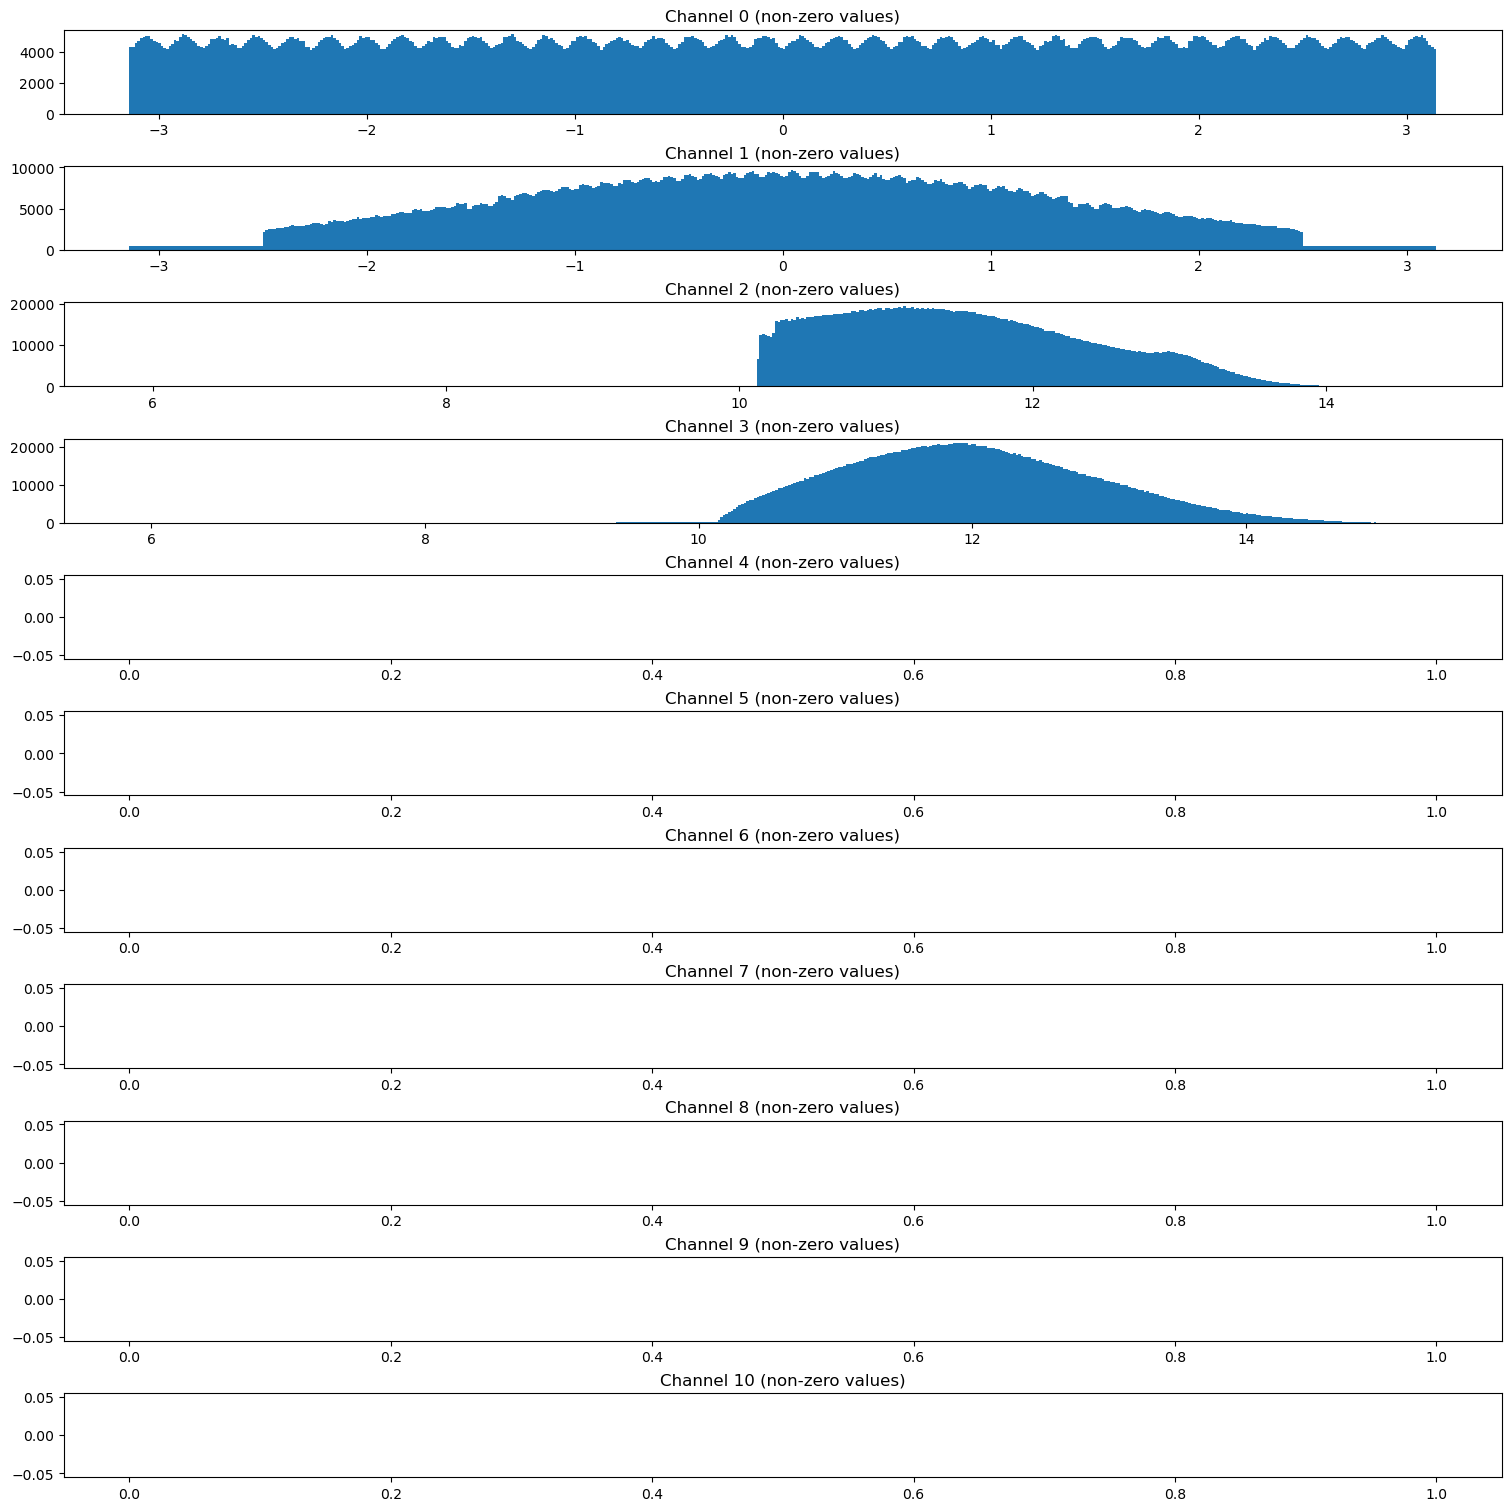

In [7]:
# Actual scaling/ normalisation

# Plot the histograms
plot_feature_histograms(X_train)

In [8]:
# Calculate Parameter Features
# df = pd.DataFrame(X_train.numpy())
feature_parameters = calculate_feature_parameters(X_train)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(feature_parameters)

    Channel   Skewness    Kurtosis        IQR       0/    Min/Max
0         0   0.000200    0.543496   0.104681  2258323   6.283180
1         1   0.000076    1.145267   0.381086  2016665   6.283110
2         2  -0.206158   -1.904668  11.565677  2016665  14.751690
3         3  -0.205447   -1.904386  12.062708  2016665  15.388658
4         4   1.064004   -0.867894   1.000000  3374003   1.000000
5         5   2.274638    3.173977   0.000000  4019834   1.000000
6         6  22.430339  501.120348   0.000000  4582430   1.000000
7         7   6.240825   36.947910   0.000000  4481981   1.000000
8         8   6.420485   39.222737   0.000000  4487621   1.000000
9         9   4.988107   22.881228   0.000000  4426601   1.000000
10       10   5.133061   24.348317   0.000000  4434865   1.000000


In [9]:
#  Set-Up pre-processing

preprocessing_methods = {}

""" 
- - - - 05/04 Very interesting and wrong  - - - -
1. For features with high skewness (>|1|) or high kurtosis (>|2|), 
you can try applying the Yeo-Johnson power transform to reduce the skewness and kurtosis, 
making the distribution more symmetric and closer to a normal distribution.

2. For features with a small IQR (e.g., <|1|), you can use robust scaling, 
as it's less sensitive to outliers. 
        >> WRONG SHOULD BE HIGH IQR >1

3. For features with a large difference between the minimum and maximum values 
(order of magnitude > 1), you can try custom scaling or min-max normalization to 
bring the range of the data within a specific interval.
"""

# Based on chatGPT's suggestions:
custom_scaling_columns = [0, 1, 2, 3]
robust_scaling_columns = []
yeo_johnson_power_transform_columns = []
min_max_normalization_columns = []
max_abs_scaling_columns = []

# Update the preprocessing_methods dictionary using a dictionary comprehension
preprocessing_methods.update({column: "custom_scaling" for column in custom_scaling_columns} | 
                             {column: "robust_scaling" for column in robust_scaling_columns} |
                             {column: "yeo_johnson_power_transform" for column in yeo_johnson_power_transform_columns} |
                             {column: "min_max_normalization" for column in min_max_normalization_columns} |
                             {column: "max_abs_scaling" for column in max_abs_scaling_columns})

In [10]:
X_train_pp, X_val_pp, X_test_pp = preprocess_features_complete(X_train, X_val, X_test, preprocessing_methods)

In [11]:
# Calculate Parameter Features
feature_parameters = calculate_feature_parameters(X_train_pp)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(feature_parameters)

    Channel   Skewness    Kurtosis        IQR       0/    Min/Max
0         0   0.000209    0.543531   0.104689  2258323   6.283180
1         1   0.000096    1.145273   0.381099  2016665   6.283110
2         2  -0.206119   -1.904686  11.565651  2016665  14.751690
3         3  -0.205408   -1.904402  12.062685  2016665  15.388658
4         4   1.063968   -0.867777   1.000000  3374003   1.732258
5         5   2.274605    3.174070   0.000000  4019834   1.732258
6         6  22.430339  501.120348   0.000000  4582430   1.000000
7         7   6.240791   36.948074   0.000000  4481981   1.732258
8         8   6.420455   39.222913   0.000000  4487621   1.681920
9         9   4.988045   22.881406   0.000000  4426601   1.732258
10       10   5.132948   24.348646   0.000000  4434865   1.732258


In [12]:
# create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_pp, Y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val_pp, Y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test_pp, Y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Create split-test loaders
Y_test_label = torch.tensor(label_np_test).float()

# Indices of signal data (label 1)
signal_indices = (Y_test_label == 1).nonzero(as_tuple=True)[0]

# Create new tensors/datasets/dataloaders for each background process
X_test_H = torch.cat([X_test_pp[signal_indices], X_test_pp[(Y_test_label == 2).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_H = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 2).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_H = torch.where(Y_test_H > 1, 0, 1)
test_H_dataset = TensorDataset(X_test_H, Y_test_H)
test_H_loader = DataLoader(test_H_dataset, batch_size=64, shuffle=False)

X_test_W = torch.cat([X_test_pp[signal_indices], X_test_pp[(Y_test_label == 3).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_W = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 3).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_W = torch.where(Y_test_W > 1, 0, 1)
test_W_dataset = TensorDataset(X_test_W, Y_test_W)
test_W_loader = DataLoader(test_W_dataset, batch_size=64, shuffle=False)

X_test_WW = torch.cat([X_test_pp[signal_indices], X_test_pp[(Y_test_label == 4).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_WW = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 4).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_WW = torch.where(Y_test_WW > 1, 0, 1)
test_WW_dataset = TensorDataset(X_test_WW, Y_test_WW)
test_WW_loader = DataLoader(test_WW_dataset, batch_size=64, shuffle=False)

X_test_Z = torch.cat([X_test_pp[signal_indices], X_test_pp[(Y_test_label == 5).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_Z = torch.cat([Y_test_label[signal_indices], Y_test_label[(Y_test_label == 5).nonzero(as_tuple=True)[0]]], dim=0)
Y_test_Z = torch.where(Y_test_Z > 1, 0, 1)
test_Z_dataset = TensorDataset(X_test_Z, Y_test_Z)
test_Z_loader = DataLoader(test_Z_dataset, batch_size=64, shuffle=False)

In [13]:
# Sanity Check
print(torch.unique(Y_test_H, return_counts=True))
print(X_test_H.shape)
print(torch.unique(Y_test_W, return_counts=True))
print(torch.unique(Y_test_WW, return_counts=True))
print(torch.unique(Y_test_Z, return_counts=True))
print(torch.unique(Y_test_label, return_counts=True))
print("- - - - - - -")
print(torch.unique(Y_train, return_counts=True))
print(torch.unique(Y_val, return_counts=True))

(tensor([0, 1]), tensor([ 3552, 15375]))
torch.Size([18927, 11, 19, 1])
(tensor([0, 1]), tensor([ 3710, 15375]))
(tensor([0, 1]), tensor([ 3779, 15375]))
(tensor([0, 1]), tensor([ 3791, 15375]))
(tensor([1., 2., 3., 4., 5.]), tensor([15375,  3552,  3710,  3779,  3791]))
- - - - - - -
(tensor([0., 1.]), tensor([120299, 121359]))
(tensor([0., 1.]), tensor([14941, 15266]))


# Model 1.1: Simple CNN (no PP) >> doesnt learn much

In [70]:
class CNN_h5_Simple_01(nn.Module):
    def __init__(self):
        super(CNN_h5_Simple_01, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv1d(11, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2)  # Dropout layer
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.3)  # Dropout layer
        )
        
        self.fc1 = nn.Linear(256, 1000)
        self.drop = nn.Dropout(0.5)  # Dropout layer
        self.fc2 = nn.Linear(1000, 2)
        
    def forward(self, x):
        x = x.squeeze(-1)  # Removing last dimension of size 1
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


In [67]:
# Instantiate the model
model = CNN_h5_Simple_01()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

model, train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, scheduler, 
                                                                    dataloaders, num_epochs=100, patience=10)

# Save the model
torch.save(model.state_dict(),
           f"G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Simple_01")

Epoch 0/99
----------


ValueError: Target size (torch.Size([64, 1, 2])) must be the same as input size (torch.Size([64, 2]))

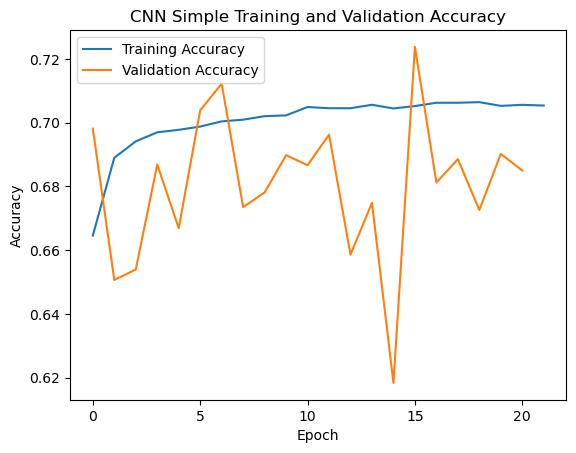

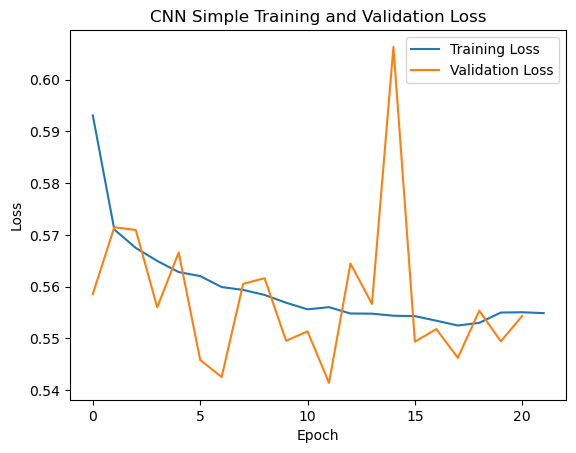

In [13]:
# Plot the training and validation accuracy versus the epoch number
plt.figure()
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Simple Training and Validation Accuracy')
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_02_TrainVal_Acc")
plt.savefig(filename)
plt.show()

# Plot the training and validation loss versus the epoch number
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Simple Training and Validation Loss')
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_02_TrainVal_Loss")
plt.savefig(filename)
plt.show()

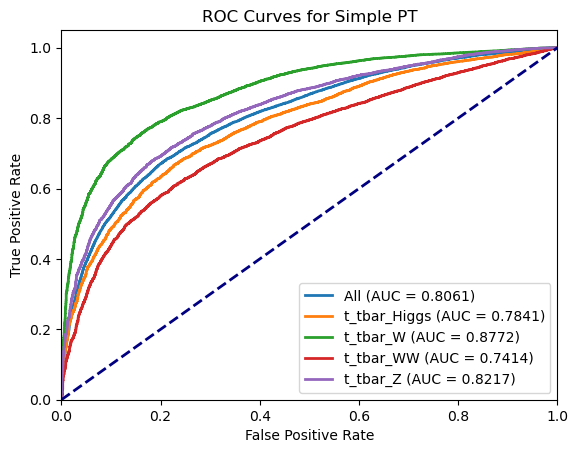

ROC AUC scores for all test sets: [0.8061021368870647, 0.7840606917893503, 0.8771810225056429, 0.7414407476490747, 0.8216505244556535]


In [47]:
# Evaluate the Model on the test sets:
test_loaders = [test_loader, test_H_loader, test_W_loader, test_WW_loader, test_Z_loader]
test_label = ["All", "t_tbar_Higgs", "t_tbar_W", "t_tbar_WW", "t_tbar_Z"]

roc_auc_scores = []
plt.figure()

for i, test_loader in enumerate(test_loaders):    
    model.load_state_dict(torch.load("G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Simple_02"))
    model.eval()
    
    #print(f"First batch of data from test_loader {i}: {next(iter(test_loader))}")  # Print the first batch of data
    
    fpr, tpr, roc_auc = test_model(model, test_loader)
    roc_auc_scores.append(roc_auc)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None, estimator_name=f"{test_label[i]} (AUC = {roc_auc:.4f})")
    display.plot(ax=plt.gca(), linewidth=2, color=f"C{i}")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Simple PT')
plt.legend(loc="lower right")
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_02_ROC")
plt.savefig(filename)
plt.show()

print("ROC AUC scores for all test sets:", roc_auc_scores)

# Model 1.2: Simple CNN w/ PP

In [14]:
class CNN_h5_Simple_02(nn.Module):
    def __init__(self):
        super(CNN_h5_Simple_02, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv1d(11, 32, kernel_size=4, stride=1, padding=1), # Here I changed kernel to 4, compared to 3 in previous model.
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2)  # Dropout layer
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.3)  # Dropout layer
        )
        
        self.fc1 = nn.Linear(256, 1000)
        self.drop = nn.Dropout(0.5)  # Dropout layer
        self.fc2 = nn.Linear(1000, 1)
        
    def forward(self, x):
        x = x.squeeze(-1)  # Removing last dimension of size 1
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x
    
# Instantiate the model
model = CNN_h5_Simple_02()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [17]:
# Instantiate the model
model = CNN_h5_Simple_02()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

model, train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, scheduler, 
                                                                    dataloaders, num_epochs=100, patience=10)

# Save the model
torch.save(model.state_dict(),
           f"G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Simple_03")

Epoch 0/99
----------
train Loss: 0.5911 Acc: 0.6684
val Loss: 0.5539 Acc: 0.6973
Learning Rate: 0.001
Best validation loss so far: 0.5538505366709096

Epoch 1/99
----------
train Loss: 0.5641 Acc: 0.6987
val Loss: 0.5619 Acc: 0.6713
Early stopping counter: 1 out of 10
Learning Rate: 0.001
Best validation loss so far: 0.5538505366709096

Epoch 2/99
----------
train Loss: 0.5602 Acc: 0.7023
val Loss: 0.5452 Acc: 0.7169
Learning Rate: 0.001
Best validation loss so far: 0.5451738325333324

Epoch 3/99
----------
train Loss: 0.5571 Acc: 0.7052
val Loss: 0.5539 Acc: 0.6878
Early stopping counter: 1 out of 10
Learning Rate: 0.001
Best validation loss so far: 0.5451738325333324

Epoch 4/99
----------
train Loss: 0.5549 Acc: 0.7070
val Loss: 0.5468 Acc: 0.7028
Early stopping counter: 2 out of 10
Learning Rate: 0.0001
Best validation loss so far: 0.5451738325333324

Epoch 5/99
----------
train Loss: 0.5429 Acc: 0.7160
val Loss: 0.5539 Acc: 0.6933
Early stopping counter: 3 out of 10
Learning Rate

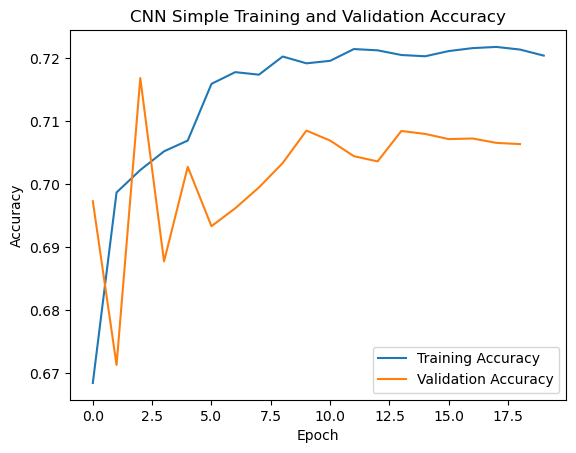

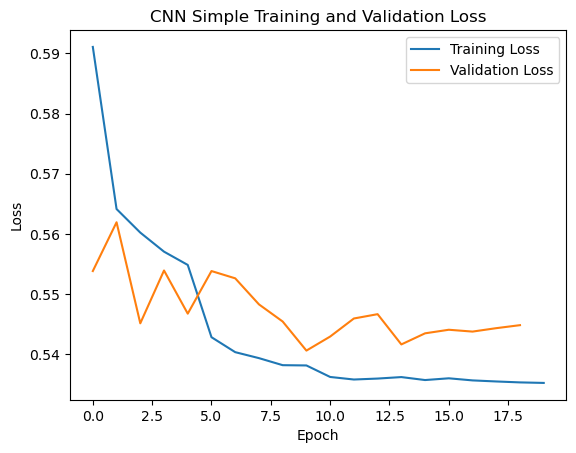

In [18]:
# Plot the training and validation accuracy versus the epoch number
plt.figure()
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Simple Training and Validation Accuracy')
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_03_TrainVal_Acc")
plt.savefig(filename)
plt.show()

# Plot the training and validation loss versus the epoch number
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Simple Training and Validation Loss')
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_03_TrainVal_Loss")
plt.savefig(filename)
plt.show()

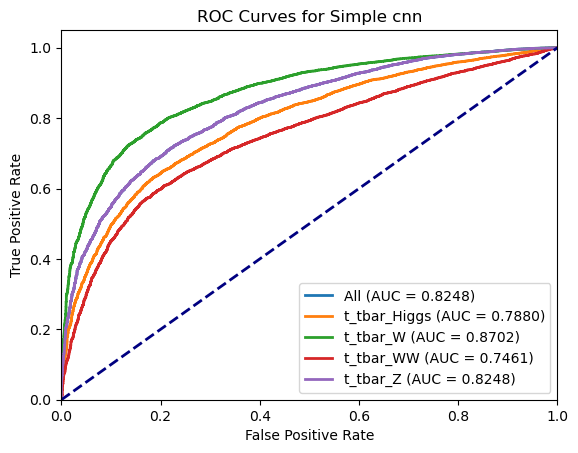

ROC AUC scores for all test sets: [0.8247717036284054, 0.7880132480041017, 0.8701562378103566, 0.746142735743314, 0.8247717036284054]


In [25]:
# Evaluate the Model on the test sets:
test_loaders = [test_loader, test_H_loader, test_W_loader, test_WW_loader, test_Z_loader]
test_label = ["All", "t_tbar_Higgs", "t_tbar_W", "t_tbar_WW", "t_tbar_Z"]

roc_auc_scores = []
plt.figure()

for i, test_loader in enumerate(test_loaders):    
    model.load_state_dict(torch.load("G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Simple_03"))
    model.eval()
    
    # print(f"First batch of data from test_loader {i}: {next(iter(test_loader))}")  # Print the first batch of data
    
    fpr, tpr, roc_auc = test_model(model, test_loader)
    roc_auc_scores.append(roc_auc)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None, estimator_name=f"{test_label[i]} (AUC = {roc_auc:.4f})")
    display.plot(ax=plt.gca(), linewidth=2, color=f"C{i}")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Simple cnn')
plt.legend(loc="lower right")
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_03_ROC")
plt.savefig(filename)
plt.show()

print("ROC AUC scores for all test sets:", roc_auc_scores)

In [19]:
# ROC AUC scores for all test sets: [0.8247717036284054, 0.7880132480041017, 0.8701562378103566, 0.746142735743314, 0.8247717036284054]

### Re-Evalutating as a Test -> THESE ARE THE GOOD RESULTS

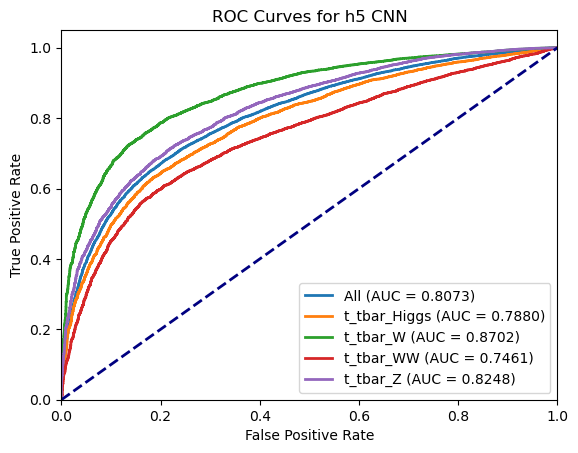

ROC AUC scores for all test sets: [0.807287326457407, 0.7880132480041017, 0.8701562378103566, 0.746142735743314, 0.8247717036284054]


In [15]:
# Evaluate the Model on the test sets:
test_loaders = [test_loader, test_H_loader, test_W_loader, test_WW_loader, test_Z_loader]
test_label = ["All", "t_tbar_Higgs", "t_tbar_W", "t_tbar_WW", "t_tbar_Z"]

roc_auc_scores = []
plt.figure()

for i, test_loader in enumerate(test_loaders):    
    model.load_state_dict(torch.load("CNN_h5_Simple_03"))
    model.eval()
    
    # print(f"First batch of data from test_loader {i}: {next(iter(test_loader))}")  # Print the first batch of data
    
    fpr, tpr, roc_auc = test_model(model, test_loader)
    roc_auc_scores.append(roc_auc)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None, estimator_name=f"{test_label[i]} (AUC = {roc_auc:.4f})")
    display.plot(ax=plt.gca(), linewidth=2, color=f"C{i}")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for h5 CNN')
plt.legend(loc="lower right")
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_03_ROC")
plt.savefig(filename)
plt.show()

print("ROC AUC scores for all test sets:", roc_auc_scores)

In [20]:
# ROC AUC scores for all test sets: [0.807287326457407, 0.7880132480041017, 0.8701562378103566, 0.746142735743314, 0.8247717036284054]

### Just evaluating MODEL 2

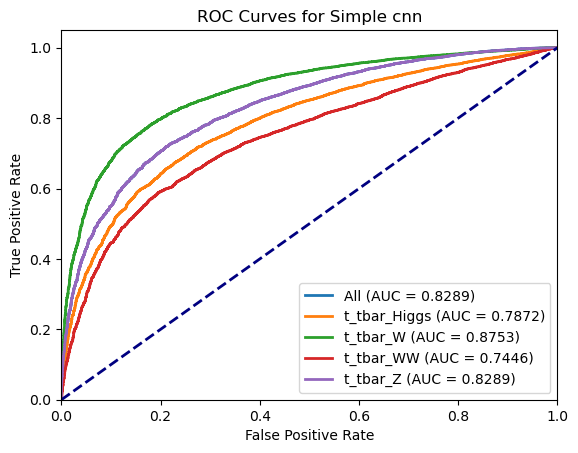

ROC AUC scores for all test sets: [0.8289273053637949, 0.7872305537244563, 0.8753283807770692, 0.744627576013786, 0.8289273053637949]


In [26]:
# Evaluate the Model on the test sets:
test_loaders = [test_loader, test_H_loader, test_W_loader, test_WW_loader, test_Z_loader]
test_label = ["All", "t_tbar_Higgs", "t_tbar_W", "t_tbar_WW", "t_tbar_Z"]

roc_auc_scores = []
plt.figure()

for i, test_loader in enumerate(test_loaders):    
    model.load_state_dict(torch.load("G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Simple_02"))
    model.eval()
    
    # print(f"First batch of data from test_loader {i}: {next(iter(test_loader))}")  # Print the first batch of data
    
    fpr, tpr, roc_auc = test_model(model, test_loader)
    roc_auc_scores.append(roc_auc)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None, estimator_name=f"{test_label[i]} (AUC = {roc_auc:.4f})")
    display.plot(ax=plt.gca(), linewidth=2, color=f"C{i}")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Simple cnn')
plt.legend(loc="lower right")
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_02_ROC")
plt.savefig(filename)
plt.show()

print("ROC AUC scores for all test sets:", roc_auc_scores)

# Model 2: Complex CNN w/ APP UNFINISHED

In [ ]:
class CNN_h5_Complex(nn.Module):
    def __init__(self):
        super(CNN_h5_Complex, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(11, 64, kernel_size=4, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2)  
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.3)  
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.4)  
        )

        self.fc1 = nn.Linear(512, 2000)  # Increased the size here
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(2000, 1)  # Increased the size here

    def forward(self, x):
        x = x.squeeze(-1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)  # Added this layer in forward pass
        x = x.view(x.size(0), -1)  
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


In [27]:
class CNN_h5_Complex(nn.Module):
    def __init__(self, dropout_rate, n_conv_layers, n_filters):
        super(CNN_h5_Complex, self).__init__()
        
        # Calculate the output size of the last convolutional layer
        fc1_in_features = n_filters * (2 ** (n_conv_layers - 1)) * 256
        
        self.convs = nn.ModuleList()
        for i in range(n_conv_layers):
            in_channels = 11 if i == 0 else n_filters * (2 ** (i - 1))
            out_channels = n_filters * (2 ** i)
            conv = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2, stride=2),
                nn.Dropout(dropout_rate)
            )
            self.convs.append(conv)
        
        self.fc1 = nn.Linear(fc1_in_features, 2000)
        self.drop = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(2000, 1)
        
    def forward(self, x):
        x = x.squeeze(-1)
        for conv in self.convs:
            x = conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

In [28]:
# Instantiate the model
model = CNN_h5_Complex()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

TypeError: __init__() missing 3 required positional arguments: 'dropout_rate', 'n_conv_layers', and 'n_filters'

In [34]:
def objective(trial):
    # 1. Define the hyperparameters to optimize
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_filters = trial.suggest_categorical('n_filters', [32, 64, 128, 256])
    
    # 2. Initialize the model with the hyperparameters
    model = CNN_h5_Complex(dropout_rate, n_conv_layers, n_filters)
    model.to(device)
    
    # 3. Define the loss function and the optimizer with the learning rate
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
   # We can add more data loaders if we have multiple datasets
    dataloaders = {
        'train': train_loader,  # assuming train_loader is predefined
        'val': val_loader        # assuming val_loader is predefined
    }

    # Call the training function
    model, train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, scheduler, dataloaders, num_epochs=20, patience=10)
    
    # We tell Optuna that we want to minimize this value by returning it
    return val_losses[-1] 

num_epochs = 20
patience = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define a storage location to enable checkpointing
storage_location = "sqlite:///CNN_h5_Complex_Optuna_storage.db"
study_name = 'CNN_h5_Complex_Optuna'
study = optuna.create_study(study_name=study_name, storage=storage_location, load_if_exists=True)

[I 2023-05-31 14:11:42,919] Using an existing study with name 'CNN_h5_Complex_Optuna' instead of creating a new one.


In [35]:
study.optimize(objective, n_trials=50)  # Set this to the number of iterations you want to run

# Run this if you've already started the study:
# study = optuna.load_study(study_name=study_name, storage='sqlite:///FCN_002_Complex_02_Optuna_storage.db')

# Print the result
best_trial = study.best_trial
print(f"Best value: {best_trial.value}")
print(f"Best hyperparameters: {best_trial.params}")


C:\Users\yoris\AppData\Local\Temp\ipykernel_21224\4105820029.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)
C:\Users\yoris\AppData\Local\Temp\ipykernel_21224\4105820029.py:4: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :func:`~optuna.trial.Trial.suggest_float` instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)


Epoch 0/19
----------


[W 2023-05-31 14:11:47,445] Trial 1 failed with parameters: {'lr': 0.008515405634230672, 'dropout_rate': 0.12011748828424987, 'batch_size': 128, 'n_conv_layers': 2, 'n_filters': 64} because of the following error: RuntimeError('mat1 and mat2 shapes cannot be multiplied (64x512 and 32768x2000)').
Traceback (most recent call last):
  File "C:\Users\yoris\anaconda3\lib\site-packages\optuna\study\_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\yoris\AppData\Local\Temp\ipykernel_21224\4105820029.py", line 24, in objective
    model, train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, scheduler, dataloaders, num_epochs=20, patience=10)
  File "C:\Users\yoris\AppData\Local\Temp\ipykernel_21224\742665733.py", line 179, in train_model
    outputs = model(inputs)
  File "C:\Users\yoris\anaconda3\lib\site-packages\torch\nn\modules\module.py", line 1130, in _call_impl
    return forward_call(*input, **kwargs)
  File "C

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x512 and 32768x2000)

In [ ]:
model, train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, scheduler, 
                                                                    dataloaders, num_epochs=100, patience=10)

# Save the model
torch.save(model.state_dict(), 
           f"G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Complex")

In [ ]:
# Plot the training and validation accuracy versus the epoch number
plt.figure()
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Simple Training and Validation Accuracy')
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_03_TrainVal_Acc")
plt.savefig(filename)
plt.show()

# Plot the training and validation loss versus the epoch number
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Simple Training and Validation Loss')
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_03_TrainVal_Loss")
plt.savefig(filename)
plt.show()

In [ ]:
# Evaluate the Model on the test sets:
test_loaders = [test_loader, test_H_loader, test_W_loader, test_WW_loader, test_Z_loader]
test_label = ["All", "t_tbar_Higgs", "t_tbar_W", "t_tbar_WW", "t_tbar_Z"]

roc_auc_scores = []
plt.figure()

for i, test_loader in enumerate(test_loaders):    
    model.load_state_dict(torch.load("G:\\My Drive\\Natuur- en Sterrenkunde Bachelor\\7\\Bachelorstage\\Models and Notebooks\\CNN\\CNN_h5_Simple_02"))
    model.eval()
    
    # print(f"First batch of data from test_loader {i}: {next(iter(test_loader))}")  # Print the first batch of data
    
    fpr, tpr, roc_auc = test_model(model, test_loader)
    roc_auc_scores.append(roc_auc)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None, estimator_name=f"{test_label[i]} (AUC = {roc_auc:.4f})")
    display.plot(ax=plt.gca(), linewidth=2, color=f"C{i}")

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Simple cnn')
plt.legend(loc="lower right")
filename = os.path.join(os.getcwd(), "CNN_h5_Simple_02_ROC")
plt.savefig(filename)
plt.show()

print("ROC AUC scores for all test sets:", roc_auc_scores)